In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import colors as clr
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib_scalebar.scalebar import ScaleBar

import pyogrio
import re
import matplotlib.patheffects as path_effects
from scipy.stats import linregress

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.outliers_influence import variance_inflation_factor

from statsmodels.iolib.summary2 import summary_col

import seaborn as sns

import exposure_fun
import importlib

importlib.reload(exposure_fun)


<module 'exposure_fun' from '/home/ben/Documents/A_PD_Work/Immigration/Online Code/exposure_fun.py'>

## Loading the data into memory

In [19]:
# The background information is to be loaded
year = 2023

# 500 x 500 grid for main analysis as it has more variables, and less suppression than the 100x100 grid. Available from 
#https://www.cbs.nl/nl-nl/dossier/nederland-regionaal/geografische-data/kaart-van-500-meter-bij-500-meter-met-statistieken

path_500_2023 = '../Grid_data/2025-cbs_vk500_2023_v2/cbs_vk500_2023_v2.gpkg'

gdf_23 = exposure_fun.renaming_keeping(path_500_2023)


# election data:
# Election information 
path_votes_2023 = '../Election_data/Verkiezingsuitslag Tweede Kamer 2023 (CSV formaat)/TK2023_uitslag.csv' # from the Kiesraad
path_local_votes_2023 = 'votes_stemB_2023.gpkg' # pre-cleaned by Bjarne

#elec_df = pd.read_csv(path_local_votes_2023, header= 0, sep=';')
elect_gdf = gpd.read_file(path_local_votes_2023)
print("If the bounds are roughly [3, 50, 7, 50] (degree-like) then we know the actual CRS",\
      " is 3426 and we need to force the overide. For context if the CRS were actualy RD (28922) ",\
      "then we would expect one bound of zero and the others far into the thousands. ", \
      "The bounds of the gdf file are:", elect_gdf.total_bounds)
elect_gdf = elect_gdf.set_crs(epsg=4326, allow_override=True)

# Step 2: Now correctly project them into RD New
elect_gdf = elect_gdf.to_crs(epsg=28992)

# raw_gdf = gpd.read_file(path_500_2023)

If the bounds are roughly [3, 50, 7, 50] (degree-like) then we know the actual CRS  is 3426 and we need to force the overide. For context if the CRS were actualy RD (28922)  then we would expect one bound of zero and the others far into the thousands.  The bounds of the gdf file are: [ 3.38495    50.76498296  7.20734741 53.47889745]


In [3]:
# The regions data
path_gem_shape_2023 = '../Grid_data/cbsgebiedsindelingen2016-2025/cbsgebiedsindelingen2023.gpkg'
wijkgrenzen = gpd.read_file(path_gem_shape_2023, layer = 'wijk_gegeneraliseerd')
gemeentegrenzen = gpd.read_file(path_gem_shape_2023, layer = 'gemeente_gegeneraliseerd')
gm_prov_df = pd.read_csv('../Gemeenten alfabetisch 2023.csv', header= 0, sep=';') # The muni to province matching

# Other regional indicators: COROP (coropgebied_gegeneraliseerd) COROP+ (coropplusgebied_gegeneraliseerd) COROP sub (coropsubgebied_gegeneraliseerd) All in cbs gebieds...
#gpd.list_layers(path_gem_shape_2023)
coropgrenzen = gpd.read_file(path_gem_shape_2023, layer = 'coropgebied_gegeneraliseerd')

coropgrenzen = coropgrenzen[['statcode', 'statnaam', 'geometry']].rename(columns = {'statcode': 'COROP_CODE', 'statnaam' : 'COROP_NAAM'}).copy()

wijkgrenzen = wijkgrenzen.merge(
    gm_prov_df[['GemeentecodeGM', 'ProvinciecodePV', 'Provincienaam']],
    left_on='gm_code',
    right_on = 'GemeentecodeGM',
    how='left',
    validate='many_to_one'
)
wijkgrenzen = wijkgrenzen.drop(columns = 'GemeentecodeGM')

gemeentegrenzen = gemeentegrenzen.merge(
    gm_prov_df[['GemeentecodeGM', 'ProvinciecodePV', 'Provincienaam']],
    left_on='statcode',
    right_on = 'GemeentecodeGM',
    how='left',
    validate='many_to_one'
)
gemeentegrenzen = gemeentegrenzen.drop(columns = 'GemeentecodeGM')


# select gemeente or wijk (Level of analysis):
region_name = 'wijk' #'wijk' # or 'gemeente'
borders_gdf = wijkgrenzen # or wijkgrenzen or gemeentegrenzen

borders_points = borders_gdf.copy()
borders_points['geometry'] = borders_points.representative_point()

border_to_corop = gpd.sjoin(
    borders_points,
    coropgrenzen,
    how="left",
    predicate="within"   # points within polygons
        )

border_to_corop = border_to_corop[['statcode', 'COROP_CODE', 'COROP_NAAM']]

borders_gdf = borders_gdf.merge(
    border_to_corop,
    on = 'statcode', 
    how = 'left',
    validate='one_to_one')

## Compute the exposure at grid cell level

The next cell runs the exposure computation. This may take a while. Note that for illustration purposes here we run it at exposure_k = 1000, while for the actual analysis we use 10,000. That is also possible in this workbook, though it takes longer to compute the exposure.

Thereafter we perform the appropriate aggregations.

In [4]:
exposure_k = 1000
k_val = exposure_k
dimension = 500
constant_c = 1
power_factor_a = 1

gdf_exposure_23 = exposure_fun.compute_exposure_gdf(gdf_23, exposure_k, dimension, constant_c, power_factor_a)


In [22]:
# align the exposure and grid data to the analysis level region data (grid into neighbourhoods or municpality)
region_grid_df_23 = exposure_fun.combine_region_grid(gdf_exposure_23,borders_gdf)

In [23]:
# aggregate the grid data into the level of anlaysis (neighbourhood or municipality)

aggregated_df_23 = exposure_fun.aggregate_regions(region_grid_df_23, agg_level = 'statcode')
# reconnect the regions border data -> here name and gemeente code is obtained.
aggregated_df_23 = borders_gdf.merge(aggregated_df_23, on="statcode", how="inner")

In [26]:
# merge the election data to the regional data
elect_df = exposure_fun.merging_election_regions(elect_gdf, borders_gdf)

aggregated_df = aggregated_df_23.merge(elect_df, how = 'left', on = 'statcode')

In [27]:
# adding the 2021 municipality votes to the 2023 dataset. This is only necessary for the study of the change in RW vote share.
gdf_votes2021 = gpd.read_file('GM2021vote.gpkg')

aggregated_df_temp = aggregated_df.copy()
aggregated_df_temp.geometry = aggregated_df_temp.geometry.representative_point()

gdf_joined = gpd.sjoin(
    aggregated_df_temp,
    gdf_votes2021,
    how="left",
    predicate="within"
)
print(f"Original number of geometries: {len(aggregated_df)}")
print(f"Rows after spatial join: {len(gdf_joined)}")

print(f"Original index is unique: {aggregated_df.index.is_unique}")
print(f"Joined index is unique: {gdf_joined.index.is_unique}")

print(
    "All joined observations originate in aggregated_df: "
    f"{gdf_joined.index.isin(aggregated_df.index).all()}"
)

# Restore the original geometries, aligned explicitly by original index
gdf_joined = gdf_joined.set_geometry(
    aggregated_df.geometry.reindex(gdf_joined.index)
)
assert gdf_joined.index.isin(aggregated_df.index).all(), (
    "Some spatial-join rows do not correspond to an original aggregated_df geometry."
)
assert len(gdf_joined) == len(aggregated_df), (
    "The spatial join changed the number of rows; inspect potential multiple matches."
)
aggregated_df = gdf_joined

# and adding the local wijk level votes from 2021 to the 2023 dataset:
wijk_votes_21 = pd.read_csv('wijk_votes_21.csv')

wijk_votes_21.head()

aggregated_df_both = aggregated_df.merge(
    wijk_votes_21,
    left_on="statcode",
    right_on="statcode_21",
    how="left",
    indicator=True           # adds _merge column
)

Original number of geometries: 3326
Rows after spatial join: 3326
Original index is unique: True
Joined index is unique: True
All joined observations originate in aggregated_df: True


The next cell is only required when studying the $\Delta_{2021,2023}$ in right-wing voting.

In [ ]:
both_elections = aggregated_df_both[aggregated_df_both['_merge']=='both']
both_elections['dif_RW'] = both_elections['RW']-both_elections['RW_wijk_21']
both_elections['dif_PVV'] = both_elections['PVV']-both_elections['PVV_wijk_21']

both_elections.plot('dif_PVV', legend = True) # Visual check for what is and isn't represented in both datasets.

Kaufmann and Goodwin [2018](https://doi.org/10.1016/j.ssresearch.2018.07.008) argue that the population size of the unit under study change the nature of the findings. The next cell applies a category to each neighbourhood in order to see if similar patterns appear in the Dutch data.

In [8]:
# This asigns a population size categorical variable to each unit of analysis to test the relationship presented by
# Kaufmann and Goodwin (2018) in Social Science Research.
small_lim_size = 1000
aggregated_df['pop_size_cat'] = aggregated_df['pop'].apply(
    lambda x: exposure_fun.pop_group(x, small_lim=small_lim_size)
)

## Graphics
Next we are ready to make plots of the data first for smaller regions, and thereafter for the whole Netherlands.

Small region analysis:
For graphics pertaining to smaller regions the following code may be used.If the whole Netherlands is to be plotted do not run this cell, but rather the next cell.

In [ ]:
# Collect the municipalities close to what you are intersted in: 
area_gdf, area_list = exposure_fun.municipalities_closeby(gemeentegrenzen, 'Westerwolde', 100)
# restrict your big dataset to those municipalities you are interested in:
area_gdf = aggregated_df[aggregated_df['gm_code'].isin(area_list)]

# Collect the municipalities close to what you are intersted in:
area2_gdf, kerkrade_list = exposure_fun.municipalities_closeby(gemeentegrenzen, "Kerkrade", 5000)
# restrict your big dataset to those municipalities you are interested in:
area2_gdf = aggregated_df[aggregated_df['gm_code'].isin(kerkrade_list)]


In [ ]:
k_val = 10000 # should match the value chosen in the beginning
vmin = 0
vmax_vote = 0.6 # 0.6 for rucphen kerkrade, and 0.515 for Rot and Ams
vmax_exp = 0.15 # 0.15 for rucphen kerkrade, and 0.4 for Rot and Ams

plot_val = 'exp' # 'exp' or 'vote'
if plot_val == 'exp':
    var_plot = f'pers_weigh_exp'
    vmax_plot = vmax_exp
    cmap = 'viridis'
    cbar_label = 'Exposure'
else:
    var_plot = 'RW'
    vmax_plot = vmax_vote
    cmap = 'RdBu'
    cbar_label = 'Right-wing vote'
    

#var_plot = f'pers_weigh_exp{k_val}' # 'RW', or f'pers_weigh_exp{k_val}'
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# First region (no legend)
area_gdf.plot(
    column=var_plot,
    vmin=vmin,
    vmax=vmax_plot,
    cmap=cmap,
    edgecolor='k',
    linewidth = 0.5,
    ax=axes[0],
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "Missing values",
    }
)

# Second region (no legend)
area2_gdf.plot(
    column=var_plot,
    vmin=vmin,
    vmax=vmax_plot,
    cmap=cmap,
    edgecolor='k',
    linewidth = 0.5,
    ax=axes[1],
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "Missing values",
    }
)

# Remove axes
for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_anchor('C')
    ax.axis('off')
    ax.add_artist(ScaleBar(1))

axes[0].set_title('Westerwolde') # Rucphen
axes[1].set_title('Kerkrade')
# Create one shared colorbar
norm = Normalize(vmin=vmin, vmax=vmax_plot)
scal_m = ScalarMappable(norm=norm, cmap=cmap)
scal_m._A = []  # required for matplotlib < 3.7
plt.tight_layout()

cbar = fig.colorbar(scal_m, ax=axes, fraction=0.1, pad=0.002, shrink = 0.9)
cbar.set_label(cbar_label)

plt.show()

Whole country:
For graphics (and regression study) of the whole Netherlands run the following cell instead of the cell above. 

Index(['statcode', 'jrstatcode', 'statnaam', 'rubriek', 'id', 'geometry',
       'ProvinciecodePV', 'Provincienaam'],
      dtype='str')
    statcode  jrstatcode       statnaam   rubriek   id  \
147   GM0518  2023GM0518  's-Gravenhage  gemeente  148   

                                              geometry ProvinciecodePV  \
147  MULTIPOLYGON (((80736.165 460589.486, 82498.81...            PV28   

    Provincienaam  
147  Zuid-Holland  


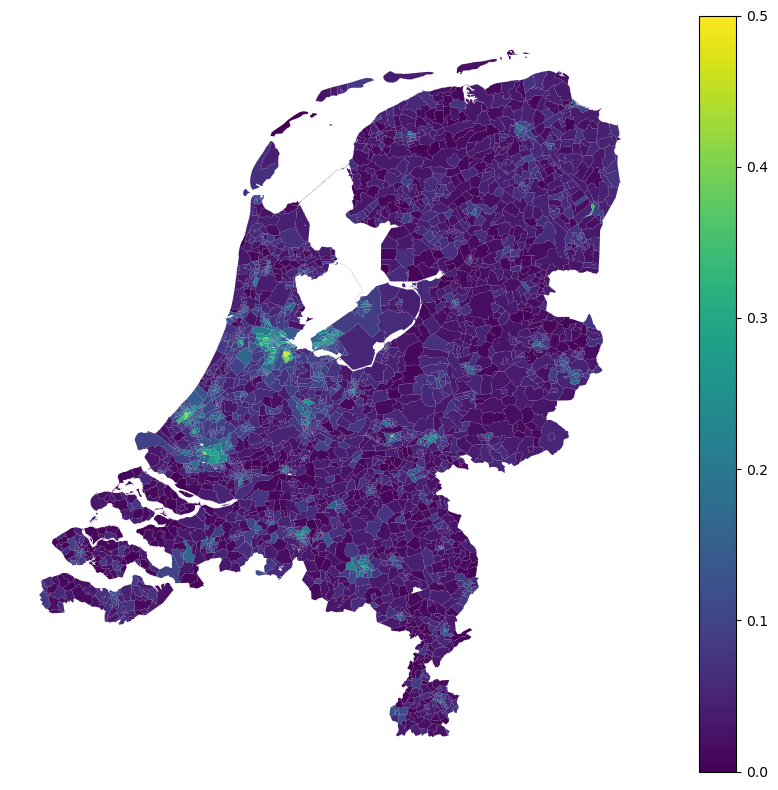

In [9]:
area_gdf = aggregated_df
print(gemeentegrenzen.columns)
print(gemeentegrenzen[gemeentegrenzen['statcode']=='GM0518'])

fig = area_gdf.plot(column = f'pers_weigh_exp', figsize = (10,8), legend = True)
fig.axis('off')
plt.tight_layout()

## Regression analysis

Now we apply the transformations to the data required to perform the regression analysis. Furthermore we restrict the dataset without NAs. The first following cell performs this for the main model specification, the cell thereafter is required when studying the $\Delta_{2021,2023}$ in right-wing voting. 

In [10]:
'''
Now we apply the data transformations (scaling, and logarithms),
Then we restrict the data to rows without missing values.
'''

area_gdf = exposure_fun.log_scaling(area_gdf, 'woz_pop_mean')
area_gdf = exposure_fun.log_scaling(area_gdf, 'oad_pop_mean')
area_gdf = exposure_fun.zscore_scaling(area_gdf, 'woz_pop_mean')
area_gdf = exposure_fun.zscore_scaling(area_gdf, 'oad_pop_mean')

k_val = 10000

area_study = area_gdf.dropna(subset=[f'pers_weigh_exp', 'RW', 'PVV', 'woz_pop_mean_log_scaled', 'oad_pop_mean_log_scaled',
                                       'share_15_to_25', 'share_25_to_45', 'share_45_to_65', 'ProvinciecodePV', 
                                     'COROP_CODE',]) # 'pop_size_cat','share_WW','RW_21'])
print("The full dataset looking at only 2023 voting has neighbourhoods:",len(area_study))

The full dataset looking at only 2023 voting has neighbourhoods: 2816


In [ ]:
both_elections = exposure_fun.log_scaling(both_elections, 'woz_pop_mean')
both_elections = exposure_fun.log_scaling(both_elections, 'oad_pop_mean')
both_elections = exposure_fun.zscore_scaling(both_elections, 'woz_pop_mean')
both_elections = exposure_fun.zscore_scaling(both_elections, 'oad_pop_mean')

both_elections = both_elections.dropna(subset=[f'pers_weigh_exp', 'dif_RW', 'dif_PVV', 'RW', 'PVV', 'woz_pop_mean_log_scaled', 'oad_pop_mean_log_scaled',
                                       'share_15_to_25', 'share_25_to_45', 'share_45_to_65', 'ProvinciecodePV', 'COROP_CODE', 'share_WW', 'RW_21', 'PVV_21'])


print("The number of neighbourhoods having data for both the 2021 and the 2023 election is:",len(both_elections))

In [13]:
# Define your regression model here for instance the definition of model. add + C(COROP_CODE) to obtain M6

formula = f'RW ~ pers_weigh_exp +C(COROP_CODE)  + oad_pop_mean_log_scaled + woz_pop_mean_log_scaled + share_15_to_25 + share_25_to_45 + share_45_to_65'
results_name = 'Corop'


In [14]:
# Run the regression and print the results.
model_ols = smf.ols(formula, data=area_study)
results_ols = model_ols.fit(cov_type = 'HC1') 

#results_ols.save(f'Regression/OLS_{results_name}_{region_name}_k{k_val}.pkl')
print(results_ols.summary())
#print(results_ols.summary().as_latex())

table = summary_col(
    [results_ols],
    stars=True,
    float_format='%0.3f',
    model_names=['OLS'],
    info_dict={
        'N':lambda x: f"{int(x.nobs)}",
        'R2':lambda x: f"{x.rsquared:.3f}"
    }
)

#print(table.as_latex())

                            OLS Regression Results                            
Dep. Variable:                     RW   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     81.61
Date:                Tue, 25 Aug 2026   Prob (F-statistic):               0.00
Time:                        09:13:07   Log-Likelihood:                 4163.9
No. Observations:                2816   AIC:                            -8236.
Df Residuals:                    2770   BIC:                            -7962.
Df Model:                          45                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

## Regression plots

For regressions without fixed effects we make informative graphics by scatter plotting the exposure and right-wing vote share along with the regression fit.

In [ ]:
# For the scatter plots with regression lines we use this, though this only works without the categorical Fixed effects variables
# (remove + C(COROP_CODE) from the formula above, and then one has M2 which can be plotted).
x_vals = np.linspace(
    area_study[f'pers_weigh_exp'].min(),
    area_study[f'pers_weigh_exp'].max(),
    100
)

base = area_study.mean(numeric_only=True)

plot_df = pd.DataFrame({
    f'pers_weigh_exp': x_vals,
    'oad_pop_mean_log_scaled': base['oad_pop_mean_log_scaled'],
    'woz_pop_mean_log_scaled': base['woz_pop_mean_log_scaled'],
    'share_15_to_25': base['share_15_to_25'],
    'share_25_to_45': base['share_25_to_45'],
    'share_45_to_65': base['share_45_to_65']
})

pred_res = results_ols.get_prediction(plot_df)
pred_summary = pred_res.summary_frame(alpha=0.05)  # 95% CI

plot_df['pred'] = pred_summary['mean']
plot_df['ci_lower'] = pred_summary['mean_ci_lower']
plot_df['ci_upper'] = pred_summary['mean_ci_upper']

x_var = f'pers_weigh_exp'
ax = sns.jointplot(
    data=area_study[area_study['pop_size_cat'].isin(['small', 'medium', 'large'])],
    x=x_var,
    y='RW', 
    color = 'k',
    alpha = 0.3
)

ax.ax_joint.plot(x_vals, plot_df['pred'], color='red')

ax.ax_joint.fill_between(
    x_vals,
    plot_df['ci_lower'],
    plot_df['ci_upper'],
    color='red',
    alpha=0.2
)

plt.xlabel('Exposure to immigrants')
plt.ylabel('Right-wing, anti-immigrant voting')
#plt.savefig(f'Exposure_RW_{dimension}m_k{k_val}_yr{year}_OLS_base_{results_name}.png', dpi = 260)

In [42]:
from importlib.metadata import version
from pathlib import Path

packages = [
    "geopandas",
    "pandas",
    "numpy",
    "matplotlib",
    "matplotlib-scalebar",
    "pyogrio",
    "scipy",
    "statsmodels",
    "seaborn",
]

requirements = [f"{package}=={version(package)}" for package in packages]

Path("requirements.txt").write_text("\n".join(requirements) + "\n")
print("\n".join(requirements))

geopandas==1.1.1
pandas==3.0.0
numpy==2.4.1
matplotlib==3.10.8
matplotlib-scalebar==0.9.0
pyogrio==0.10.0
scipy==1.16.3
statsmodels==0.14.6
seaborn==0.13.2
